# CarRacing-v3 Deep Q-Network

This notebook will explore applying DQNs to the 'CarRacing-v3' gymnasium environment.

In [2]:
import random
import gymnasium as gym
import torch
import numpy as np

from gymnasium import Space
from gymnasium.wrappers import RecordEpisodeStatistics, RecordVideo
from torch import nn
from torch.types import Number
from torchrl.envs import GymWrapper
from torchrl.envs.libs import set_gym_backend, GymEnv
from collections import deque, namedtuple
from itertools import count

In [3]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

## Deep Q-Networks

Regular Q-Networks use a table to store q-values, however when the state space is too large we cannot efficiently store and extract information from this table.

Deep Q-Networks use a deep neural network as a representation of this table, so we can pass in the state and get the approximated values q-values for all actions. We then use the highest q-valued action to select the best action.

In [94]:
class DQN(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            # Input (B, 4, 48, 48)
            nn.Conv2d(4, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            #Input (B, 64, 24, 24)
            nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            # Input (B, 64, 12, 12)
            nn.Conv2d(64, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            # Input (B, 32, 12, 12)
            nn.Conv2d(32, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            # (B, 32, 6, 6)
            nn.Flatten(
                start_dim=1,
            ),
            # Input (B, 1152)
            nn.Linear(32 * 6 * 6, 16 * 6 * 6),
            nn.ReLU(),
            #Input (B, 576),
            nn.Linear(16 * 6 * 6, 5)
            # Output (B, 5)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)

    # Returns a epislon-greedy action
    def epsilon_action(
        self, epsilon: float, state: torch.Tensor, action_space: Space
    ) -> Number:
        r = random.random()
        if r < epsilon:
            return action_space.sample()

        with torch.no_grad():
            return self.forward(state.reshape((1, 4, 48, 48))).argmax().item()

## Experience Replay

During tabular Q-learning, we learn by building a Q-table. This works because each state–action update is independent and does not directly interfere with other entries.

However, in a DQN, applying this principle directly would lead to unstable training, because the neural network generalises across states and actions. An update for one transition affects the Q-values of many other states, and consecutive samples are highly correlated. As a result, the network would need to learn from non-stationary and correlated data, which can cause divergence or oscillation.

This is mitigated using experience replay, where transitions are stored and randomly sampled during training, breaking temporal correlations and stabilising learning.

To start training, the experience replay buffer is first bootstrapped with an initial set of transitions collected by acting randomly in the environment.

In [148]:
Transition = namedtuple(
    "Transition", ("observation", "action", "reward", "next_observation", "done")
)

Batch = namedtuple(
    "Batch", ("observations", "actions", "rewards", "next_observations", "episodes_over")
)

class ReplayBuffer:
    def __init__(self, capacity: int, batch_size: int):
        self.store = deque[Transition]([], maxlen=capacity)
        self.batch_size = batch_size

    def get_batch(self) -> Batch:
        transitions = random.sample(self.store, self.batch_size)

        return Batch(
            torch.cat([t.observation for t in transitions]),
            torch.tensor([t.action for t in transitions], dtype=torch.int),
            torch.tensor([t.reward for t in transitions]),
            torch.cat([t.next_observation for t in transitions]),
            torch.tensor([t.done for t in transitions], dtype=torch.int),
        )
        
    def __len__(self) -> int:
        return len(self.store)

    def push(self, t: Transition) -> None:
        self.store.append(t)

    def bootstrap(self, env: gym.Env):
        observation, _ = env.reset()
        
        for _ in range(2 * self.batch_size):
            random_action = env.action_space.sample()

            next_observation, reward, terminated, truncated, _ = env.step(random_action)

            t = Transition(
                observation,
                random_action,
                reward,
                next_observation,
                terminated or truncated,
            )

            self.push(t)

            if terminated or truncated:
                observation, _ = env.reset()
                continue

            observation = next_observation

        env.reset()

# Training Constants

- Gamma - the discount factor (how far-sighted should the agent be?)
- Epsilon - the probability that the next action is chosen randomly, this ranges from `EPSILON_START` to `EPSILON_END` in `EPSILON_DECAY` steps
- Learning rate - learning rate for gradient descent
- Batch size - the number of transitions to get out of the experience replay buffer at a time for training
- Replay buffer size - the total number of transitions stored in the experience buffer at one time
- Episodes - the number of episodes to train the agent
- `TARGET_UPDATE_SAMPLE_COUNT` - the number of steps required needed to update the target network
- `RECORD_VIDEO_EPISODES` - the number of episodes needed to record the next video

In [149]:
GAMMA         = 0.99    # Discount factor (how far-sighted should the agent be?)

# Epsilon is the percentage of actions that should be random
# At the start of training, actions should be majority random to allow the agent to explore
# Towards the ends, the agent should only choose actions that increase the reward
EPSILON_START = 1.0    
EPSILON_END   = 0.05
EPSILON_DECAY = 100_000 # Steps required to reach EPSILON_DECAY

LEARNING_RATE = 3e-4

BATCH_SIZE    = 32 # How much transitions are in a batch?
REPLAY_BUFFER_SIZE         = 50_000 # Total number of transitions stored in the experience buffer at one time

EPISODES                   = 1500 # Number of episodes to train the agent
TARGET_UPDATE_SAMPLE_COUNT = 2500 # Number of steps needed to update the target network

LOSS_FN: torch.nn.MSELoss  = torch.nn.MSELoss()

def get_epsilon(step):
    return (
        EPSILON_END
        + (EPSILON_START - EPSILON_END)
        * torch.exp(torch.tensor(-1.0 * step / EPSILON_DECAY)).item()
    )

# Statistical Constants
RECORD_VIDEO_EPISODES = 200

# Environment Setup

The environment has been setup in a way such that

- The observations are
    - grayscaled
    - resized to `(48, 48)`
    - frame skipped with value 4
    - stacked in size of 4's
    - rescaled from 0-1
    - turned into torch tensors
- A video is recorded to `racing-training` every `RECORD_VIDEO_EPISODES` episodes
- Statistics are recorded

In [150]:
env = gym.make("CarRacing-v3", render_mode="rgb_array", continuous=False, domain_randomize=False)
env = gym.wrappers.GrayscaleObservation(env)
env = gym.wrappers.ResizeObservation(env, (48, 48))
env = gym.wrappers.MaxAndSkipObservation(env, 4)
env = gym.wrappers.FrameStackObservation(env, stack_size=4)
env = gym.wrappers.RescaleObservation(env, 0.0, 1.0)
print(env.observation_space)
env = RecordVideo(
    env,
    video_folder="racing-training",
    name_prefix="training",
    episode_trigger=lambda x: x % RECORD_VIDEO_EPISODES == 0  # Only record every RECORD_VIDEO_EPISODES episodes
)
env = RecordEpisodeStatistics(env)
env = gym.wrappers.TransformObservation(env, lambda x: torch.Tensor(x).to(device).reshape((1, 4, 48, 48)), env.observation_space)

Box(0, 1, (4, 48, 48), uint8)


/home/subeen/subeenfiles/code/racingrl/.venv/lib/python3.12/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /home/subeen/subeenfiles/code/racingrl/src/racing-training folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [151]:
# Set all seeds to 0 for training reproducibility
random.seed(0)
torch.manual_seed(0)
state, info = env.reset(seed=0)
env.action_space.seed(0)
env.observation_space.seed(0)

0

# Training

To train the network we do the following

1. Create two identical DQNs, the q-network and target q-network
2. Bootstrap the experience buffer with some training examples (random actions)
3. Make an epsilon-greedy action and add that transition into the buffer
4. Get a batch from the experience buffer
5. Compute the q-values from the transitions using the q-network
6. Compute the target q-values from the transitions using the target q-network
7. Compute the loss betwen the predicted q-values and target q-values and optimize the loss function for the q-network
8. After `TARGET_UPDATE_SAMPLE_COUNT` steps, copy the q-network over to the target q-network

In [ ]:
replay_buffer = ReplayBuffer(REPLAY_BUFFER_SIZE, BATCH_SIZE)

q_network = DQN().to(device)
target_network = DQN().to(device)

optimizer = torch.optim.AdamW(q_network.parameters(), lr=LEARNING_RATE, amsgrad=True)

target_network.load_state_dict(q_network.state_dict())

replay_buffer.bootstrap(env)

global_steps = 0

for e in range(EPISODES):
    episode_over = False
    episode_reward = 0
    observation, info = env.reset()
    while not episode_over:
        global_steps += 1
        epsilon = get_epsilon(global_steps)

        # After TARGET_UPDATE_SAMPLE_COUNT, copy the q-network to the target network
        if global_steps % TARGET_UPDATE_SAMPLE_COUNT == 0:
            target_network.load_state_dict(q_network.state_dict())

        # Choose an epsilon-greedy action
        action = q_network.epsilon_action(epsilon, observation, env.action_space)

        # Make this action
        next_observation, reward, terminated, truncated, info = env.step(action)
        episode_reward += float(reward)
        episode_over = terminated or truncated

        # Store the transition in the Experience Replay
        t = Transition(
            observation, action, float(reward), next_observation, episode_over
        )
        replay_buffer.push(t)

        # Get a batch of transitions to train on
        batch = replay_buffer.get_batch()

        q_network.train()

        # Compute q values and target q values
        q_values = q_network.forward(batch.observations)[torch.arange(32), batch.actions]
        with torch.no_grad():
            target_q_values = batch.rewards + (
                GAMMA
                * target_network.forward(batch.next_observations).max(1).values
                * (1 - batch.episodes_over)
            )
        loss = LOSS_FN(q_values, target_q_values)

        # Train the q network
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_value_(q_network.parameters(), 10)
        optimizer.step()

        observation = next_observation

    print(
        f"Episode: {e} Reward: {episode_reward} Epsilon: {get_epsilon(global_steps)} Replay Buffer: {((float(len(replay_buffer)) / REPLAY_BUFFER_SIZE) * 100):.2f}%"
    )

In [ ]:
# Saving model
torch.save(q_network.state_dict(), "model.pth")

## Test model

This will run the environment and model in `render_mode = "human"` so you can watch it play

In [ ]:
import random
import time
from math import trunc

import gymnasium as gym
import torch

env = gym.make(
    "CarRacing-v3", render_mode="human", continuous=False, domain_randomize=False
)

random.seed(0)
torch.manual_seed(0)
state, info = env.reset(seed=0)
env.action_space.seed(0)
env.observation_space.seed(0)

q_network = DQN()
q_network.load_state_dict(torch.load("model2.pth", map_location="cpu"))

episode_over = False

observation, info = env.reset()

observation = torch.Tensor(observation).permute(2, 0, 1) / 255.0

epsilon = 0.0

while not episode_over:
    action = q_network.epsilon_action(epsilon, observation, env.action_space)
    observation, reward, terminated, truncated, info = env.step(action)
    observation = torch.Tensor(observation).permute(2, 0, 1) / 255.0

    env.render()

    episode_over = terminated or truncated


## Plot Graphs

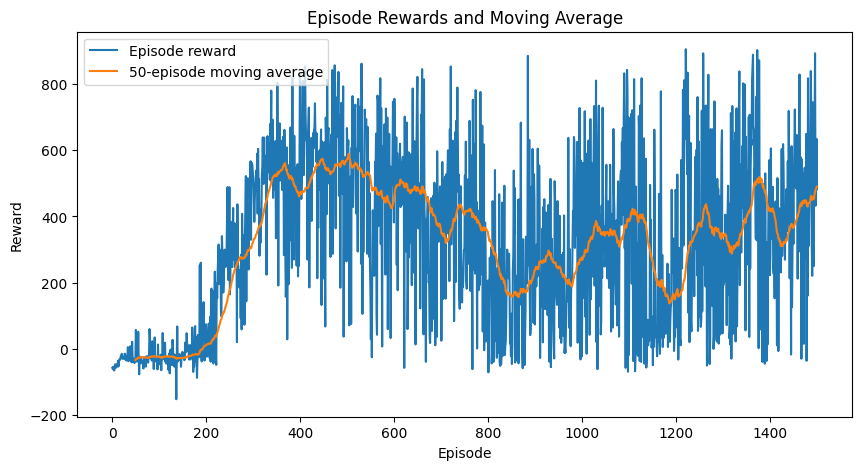

In [6]:
import matplotlib.pyplot as plt
import numpy as np

with open("results.txt", "r") as f:
    rewards = [float(line.strip()) for line in f if line.strip()]

# 2️⃣ Compute moving average
def moving_average(x, window=50):
    return np.convolve(x, np.ones(window)/window, mode="valid")

avg_rewards = moving_average(rewards, window=50)

# 3️⃣ Prepare x-axis
episodes = np.arange(len(rewards))
avg_episodes = np.arange(49, len(rewards))  # moving_average shortens the array

# 4️⃣ Plot
plt.figure(figsize=(10,5))
plt.plot(episodes, rewards, label="Episode reward")
plt.plot(avg_episodes, avg_rewards, label="50-episode moving average")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Episode Rewards and Moving Average")
plt.legend()
plt.show()